# Soil Depth

In [ ]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rasterio.mask import mask
from rasterio.windows import Window
import contextily as ctx  # For basemap tiles
import os

# Paths to the raster and shapefile
raster_path = r"\\gis.slu.se\gisdata\sgu\jorddjupsmodell\vector\epsg3006\2024-02-22\delivery\jorddjup_10x10m\jorddjup_10x10m.tif"
# Load the catchments that I am running it for
zip_catch = "catch_316.zip"

os.chdir("C:/Users/anlr0006/Repositories/top-down/Shapefiles")


# Load the shapefiles from the ZIP files
gdf_catch = gpd.read_file(f"zip://{zip_catch}")

os.chdir("C:/Users/anlr0006/Repositories/DOC_catchments")

output_folder = r"maps"  # Folder to save maps

# Ensure the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Step 1: Read the shapefile (example)
gdf = gdf_catch # .iloc[1:3]  # Adjust for the number of catchments you want to process

# Step 2: Prepare to collect results and failures
statistics_results = []
failed_ids = []

# Process each shape in the catchment dataframe
for idx, zone in gdf.iterrows():
    try:
        # Extract the geometry and bounds of the current shape
        zone_geom = zone['geometry']
        bounds = zone_geom.bounds  # (min_x, min_y, max_x, max_y)

        # Open the raster file and process the data
        with rasterio.open(raster_path) as src:
            # Ensure shapefile CRS matches raster CRS
            if gdf.crs != src.crs:
                gdf = gdf.to_crs(src.crs)

            # Convert bounds to raster pixel coordinates
            col_start, row_start = ~src.transform * (bounds[0], bounds[1])  # min_x, min_y
            col_stop, row_stop = ~src.transform * (bounds[2], bounds[3])    # max_x, max_y

            # Ensure valid window bounds
            col_start, col_stop = sorted([int(max(0, min(src.width - 1, col_start))),
                                           int(max(0, min(src.width - 1, col_stop)))] )
            row_start, row_stop = sorted([int(max(0, min(src.height - 1, row_start))),
                                           int(max(0, min(src.height - 1, row_stop)))])
            
            # Define the window
            window = Window(col_start, row_start, col_stop - col_start, row_stop - row_start)

            # Read the raster data for the window
            raster_data = src.read(1, window=window)

            # Plot the raster window and shapefile overlay
            fig, ax = plt.subplots(figsize=(10, 10))
            
            # Plot the raster with adjusted opacity (alpha controls transparency)
            ax.imshow(raster_data, cmap='gray', extent=(bounds[0], bounds[2], bounds[3], bounds[1]), alpha=0.6)
            ax.set_title(f"Catchment ID: {zone['mvm_id']}")  # Adjust ID field as necessary

            # Overlay the current shape on the plot
            gpd.GeoSeries(zone_geom).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
            
            # Add a basemap using OpenStreetMap or Stamen Terrain
            ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)  # OSM default basemap
            
            # Save the map as an image file
            map_filename = os.path.join(output_folder, f"{zone['mvm_id']}_map.png")
            plt.savefig(map_filename, dpi=300)
            plt.close()

            # Mask the raster data using the current geometry
            out_image, out_transform = mask(src, [zone_geom], crop=True)

            # Extract valid raster values and calculate statistics
            masked_values = out_image[0]
            masked_values = masked_values[masked_values != src.nodata]

            if len(masked_values) > 0:
                statistics_results.append({
                    'mvm_id': zone['mvm_id'],  # Adjust to your zone ID field
                    'mean': np.mean(masked_values),
                    'stddev': np.std(masked_values),
                    'min': np.min(masked_values),
                    'max': np.max(masked_values),
                    '25th_percentile': np.percentile(masked_values, 25),
                    '75th_percentile': np.percentile(masked_values, 75)
                })
            else:
                failed_ids.append(zone['mvm_id'])

    except Exception as e:
        # If an error occurs, log the failure ID and continue
        print(f"Failed to process {zone['mvm_id']}: {e}")
        failed_ids.append(zone['mvm_id'])

# Step 3: Save statistics to CSV
statistics_df = pd.DataFrame(statistics_results)
statistics_df.to_csv(os.path.join(output_folder, "soil_depth.csv"), index=False)

# Step 4: Log failed IDs to a text file
with open(os.path.join(output_folder, "failed.txt"), 'w') as f:
    for failed_id in failed_ids:
        f.write(f"{failed_id}\n")

print(f"Processing complete. Maps saved to {output_folder}, statistics saved to soil_depth.csv, and failed IDs saved to failed.txt.")


# NDVI

In [45]:
import ee
import geemap
# Authenticate
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-anna-lackner')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


In [24]:
import os
import geopandas as gpd

zip_catch = "shapefiles/catch_316.zip"

# Load the shapefiles from the ZIP files
gdf_catch = gpd.read_file(f"zip://{zip_catch}")

gdf_catch.to_crs(epsg=4326, inplace=True)

In [25]:
import ee
import pandas as pd
import geopandas as gpd
from datetime import datetime

# Initialize the Earth Engine API
ee.Initialize()

# Function to load the shapefile and convert it to a FeatureCollection
def geo_to_ee(gdf):
    features = []
    for idx, geometry in gdf.geometry.items():
        try:
            mvm_id = gdf.loc[idx, 'mvm_id']  # Extract mvm_id for this row
            
            # Check the geometry type and convert accordingly
            if geometry.geom_type == 'Polygon':
                ee_geom = ee.Geometry.Polygon(list(geometry.exterior.coords))
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            elif geometry.geom_type == 'MultiPolygon':
                polygons = [ee.Geometry.Polygon(list(poly.exterior.coords)) for poly in geometry.geoms]
                ee_geom = ee.Geometry.MultiPolygon(polygons)
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            elif geometry.geom_type == 'Point':
                ee_geom = ee.Geometry.Point([geometry.x, geometry.y])
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            else:
                print(f"Skipping unsupported geometry type: {geometry.geom_type}")
        except Exception as e:
            print(f"Error processing geometry {idx}: {e}")
    return ee.FeatureCollection(features)

# Load your shapefile (replace 'gdf_catch' with the actual GeoDataFrame name)
gdf = gdf_catch # .iloc[2:3]  # Example of selecting the first two rows for demonstration

# Print the DataFrame to check its structure
print("GeoDataFrame structure:")
print(gdf)
print(gdf.crs)

# Convert GeoDataFrame to Earth Engine FeatureCollection
catchments = geo_to_ee(gdf)

# Define the Landsat 8 NDVI Composite dataset (8-day composite)
Landsat_NDVI = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI')

# Define the months and years for which you want to calculate the NDVI (January to December, 2020-2021)
months = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
years = list(range(1990, 2024, 1))

# Function to generate the correct last day of the month (handling leap years)
def get_last_day_of_month(year, month):
    if month == "02":  # Special handling for February (Leap Year)
        if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)):  # Leap year check
            return f"{year}-{month}-29"  # Leap year (February 29)
        else:
            return f"{year}-{month}-28"  # Non-leap year (February 28)
    elif month in ["04", "06", "09", "11"]:  # 30-day months
        return f"{year}-{month}-30"
    else:  # 31-day months
        return f"{year}-{month}-31"

# Store results in a list
results = []

# Loop through each geometry (catchment) and calculate NDVI time series for each month and year
for idx, geometry in gdf.iterrows():
    try:
        mvm_id = geometry['mvm_id']
        print(f"Processing geometry with mvm_id: {mvm_id}")
        
        # Convert the geometry to an Earth Engine object
        shape = geo_to_ee(gdf.loc[[idx]])  # Use the current row for the geometry
        print(f"Shape for mvm_id {mvm_id} converted to Earth Engine FeatureCollection.")
        
        # Loop through each year and month to create the time series
        for year in years:
            for month in months:
                print(f"Processing month: {month} for mvm_id {mvm_id} in {year}")
                
                # Initialize the collection for the current month
                image_collection = None
                
                start_date = f"{year}-{month}-01"
                end_date = get_last_day_of_month(year, month)
                
                # Filter the Landsat NDVI data for the current month and year
                date_filter = ee.Filter.date(start_date, end_date)
                
                # Filter Landsat data by date and geometry bounds
                landsat_filtered = Landsat_NDVI \
                    .filter(date_filter) \
                    .filterBounds(shape)
                
                # Check how many images are available for the current month
                image_count = landsat_filtered.size().getInfo()
                print(f"Number of images for {month}-{year}: {image_count}")
                
                # If no images are available, skip to the next month
                if image_count == 0:
                    print(f"No images for {month}-{year} and mvm_id {mvm_id}. Skipping.")
                    continue

                # Apply the reducers separately: mean, median, and stdDev
                ndvi_mean = landsat_filtered.reduce(ee.Reducer.mean())
                ndvi_median = landsat_filtered.reduce(ee.Reducer.median())
                ndvi_stdDev = landsat_filtered.reduce(ee.Reducer.stdDev())

                # Now apply reduceRegions for each of the statistics
                stats_mean = ndvi_mean.reduceRegions(
                    collection=shape,
                    reducer=ee.Reducer.mean(),
                    scale=30,  # Set scale to 30 meters (Landsat resolution)
                    tileScale=2
                )

                stats_median = ndvi_median.reduceRegions(
                    collection=shape,
                    reducer=ee.Reducer.median(),
                    scale=30,
                    tileScale=2
                )

                stats_stdDev = ndvi_stdDev.reduceRegions(
                    collection=shape,
                    reducer=ee.Reducer.stdDev(),
                    scale=30,
                    tileScale=2
                )

                try:
                    # Get the results for each statistic (mean, median, stdDev)
                    mean_info = stats_mean.getInfo()
                    median_info = stats_median.getInfo()
                    stdDev_info = stats_stdDev.getInfo()

                    # Check if the results contain features
                    if 'features' in mean_info and len(mean_info['features']) > 0:
                        # Extract and append results for each mvm_id, month, and year
                        for i in range(len(mean_info['features'])):
                            feature_data = {
                                'month': month,
                                'year': year,
                                'mvm_id': mvm_id,
                                'NDVI_mean': mean_info['features'][i]['properties'].get('mean', None),
                                'NDVI_median': median_info['features'][i]['properties'].get('median', None),
                                'NDVI_stdDev': stdDev_info['features'][i]['properties'].get('stdDev', None),
                                # 'coordinates': mean_info['features'][i]['geometry']['coordinates']
                            }
                            results.append(feature_data)

                except Exception as e:
                    print(f"Error computing statistics for {month}-{year} and mvm_id {mvm_id}: {str(e)}")
                    # If error occurs, append None for NDVI statistics
                    feature_data = {
                        'month': month,
                        'year': year,
                        'mvm_id': mvm_id,
                        'NDVI_mean': None,
                        'NDVI_median': None,
                        'NDVI_stdDev': None,
                        # 'coordinates': None
                    }
                    results.append(feature_data)

    except Exception as e:
        print(f"Error processing mvm_id {gdf.loc[idx, 'mvm_id']}: {e}")

# Convert results to a pandas DataFrame
df = pd.DataFrame(results)

# Display the final DataFrame

out_path = r"Output\NDVI.csv"

df.to_csv(out_path, index = False)


GeoDataFrame structure:
      mvm_id        lat       lon          AU_CD     Shape_Leng    Shape_Area  \
0      593.0  6471782.0  361849.0  647591-131477  245521.736556  8.101294e+08   
1     1329.0  6414340.0  360946.0  641830-131320   10471.173440  4.418392e+06   
2     1815.0  6330290.0  473043.0  633181-142382    2780.197525  2.144475e+05   
3     1821.0  7084550.0  653124.0  708534-161332    3936.412956  4.366071e+05   
4     1817.0  6623930.0  495022.0  662723-145047    2324.498643  1.867857e+05   
..       ...        ...       ...            ...            ...           ...   
311  34693.0  6433980.0  500600.0  643296-145661  228614.449975  8.593351e+08   
312  29021.0  6211632.0  444199.0  621411-139243   85895.619679  1.959404e+08   
313  37651.0  6230990.0  375206.0  623498-132579  115689.552137  2.131711e+08   
314   1057.0  7310600.0  828291.0  731290-178692  113400.393514  3.482615e+08   
315     22.0  6728334.0  616191.0  672937-157298  382829.264151  2.451777e+09   

   

KeyboardInterrupt: 

Better structure? run next.

In [ ]:
import ee
import pandas as pd
import geopandas as gpd
from datetime import datetime
import os

# Load the shapefile
zip_catch = "shapefiles/catch_316.zip"
gdf_catch = gpd.read_file(f"zip://{zip_catch}")
gdf_catch.to_crs(epsg=4326, inplace=True)

# Initialize Earth Engine API
ee.Initialize()

# Function to calculate the last day of the month
def get_last_day_of_month(year, month):
    if month == "02":
        return f"{year}-{month}-29" if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else f"{year}-{month}-28"
    elif month in ["04", "06", "09", "11"]:
        return f"{year}-{month}-30"
    return f"{year}-{month}-31"

# Function to convert GeoDataFrame row to Earth Engine FeatureCollection
def geo_to_ee(gdf_row):
    geometry = gdf_row.geometry
    mvm_id = gdf_row['mvm_id']
    if geometry.geom_type == 'Polygon':
        ee_geom = ee.Geometry.Polygon(list(geometry.exterior.coords))
    elif geometry.geom_type == 'MultiPolygon':
        polygons = [ee.Geometry.Polygon(list(poly.exterior.coords)) for poly in geometry.geoms]
        ee_geom = ee.Geometry.MultiPolygon(polygons)
    elif geometry.geom_type == 'Point':
        ee_geom = ee.Geometry.Point([geometry.x, geometry.y])
    else:
        raise ValueError(f"Unsupported geometry type: {geometry.geom_type}")
    return ee.FeatureCollection([ee.Feature(ee_geom).set('mvm_id', mvm_id)])

# Function to compute NDVI statistics for a specific mvm_id
def process_mvm_id(gdf_row, years, months, Landsat_NDVI, output_dir):
    mvm_id = gdf_row['mvm_id']
    print(f"Processing mvm_id: {mvm_id}")
    shape = geo_to_ee(gdf_row)
    
    rows = []
    for year in years:
        for month in months:
            start_date = f"{year}-{month}-01"
            end_date = get_last_day_of_month(year, month)
            
            landsat_filtered = Landsat_NDVI \
                .filter(ee.Filter.date(start_date, end_date)) \
                .filterBounds(shape)
            
            image_count = landsat_filtered.size().getInfo()
            if image_count == 0:
                continue
            
            ndvi_mean = landsat_filtered.reduce(ee.Reducer.mean())
            ndvi_median = landsat_filtered.reduce(ee.Reducer.median())
            ndvi_stdDev = landsat_filtered.reduce(ee.Reducer.stdDev())
            
            stats_mean = ndvi_mean.reduceRegions(
                collection=shape,
                reducer=ee.Reducer.mean(),
                scale=30,
                tileScale=2
            )
            stats_median = ndvi_median.reduceRegions(
                collection=shape,
                reducer=ee.Reducer.median(),
                scale=30,
                tileScale=2
            )
            stats_stdDev = ndvi_stdDev.reduceRegions(
                collection=shape,
                reducer=ee.Reducer.stdDev(),
                scale=30,
                tileScale=2
            )
            
            try:
                mean_info = stats_mean.getInfo()
                median_info = stats_median.getInfo()
                stdDev_info = stats_stdDev.getInfo()
                
                for i in range(len(mean_info['features'])):
                    rows.append({
                        'mvm_id': mvm_id,
                        'year': year,
                        'month': month,
                        'NDVI_mean': mean_info['features'][i]['properties'].get('mean', None),
                        'NDVI_median': median_info['features'][i]['properties'].get('median', None),
                        'NDVI_stdDev': stdDev_info['features'][i]['properties'].get('stdDev', None)
                    })
            except Exception as e:
                print(f"Error processing stats for mvm_id {mvm_id} ({year}-{month}): {e}")
    
    if rows:
        output_path = os.path.join(output_dir, f"NDVI_{mvm_id}.csv")
        pd.DataFrame(rows).to_csv(output_path, index=False)
        print(f"Saved results for mvm_id {mvm_id} to {output_path}")
    else:
        print(f"No valid NDVI data found for mvm_id {mvm_id}.")

# Main processing loop
def main():
    output_dir = "Output/NDVI_Results"
    os.makedirs(output_dir, exist_ok=True)
    
    months = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
    years = list(range(1990, 2024))
    Landsat_NDVI = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI')
    
    for idx, gdf_row in gdf_catch.iterrows():
        try:
            process_mvm_id(gdf_row, years, months, Landsat_NDVI, output_dir)
        except Exception as e:
            print(f"Error processing mvm_id {gdf_row['mvm_id']}: {e}")

if __name__ == "__main__":
    main()

Processing mvm_id: 593.0
Saved results for mvm_id 593.0 to Output/NDVI_Results\NDVI_593.0.csv
Processing mvm_id: 1329.0
Saved results for mvm_id 1329.0 to Output/NDVI_Results\NDVI_1329.0.csv
Processing mvm_id: 1815.0
Saved results for mvm_id 1815.0 to Output/NDVI_Results\NDVI_1815.0.csv
Processing mvm_id: 1821.0
Saved results for mvm_id 1821.0 to Output/NDVI_Results\NDVI_1821.0.csv
Processing mvm_id: 1817.0
Saved results for mvm_id 1817.0 to Output/NDVI_Results\NDVI_1817.0.csv
Processing mvm_id: 1043.0
Saved results for mvm_id 1043.0 to Output/NDVI_Results\NDVI_1043.0.csv
Processing mvm_id: 178.0
Saved results for mvm_id 178.0 to Output/NDVI_Results\NDVI_178.0.csv
Processing mvm_id: 1869.0
Saved results for mvm_id 1869.0 to Output/NDVI_Results\NDVI_1869.0.csv
Processing mvm_id: 176.0
Saved results for mvm_id 176.0 to Output/NDVI_Results\NDVI_176.0.csv
Processing mvm_id: 1039.0
Saved results for mvm_id 1039.0 to Output/NDVI_Results\NDVI_1039.0.csv
Processing mvm_id: 1041.0
Saved results

In [31]:
# Convert results to a pandas DataFrame
df = pd.DataFrame(results)

# Display the final DataFrame

out_path = r"Output\NDVI.csv"

df.to_csv(out_path, index = False)

# PLC 8

Too difficult to get a handle on. 

# Peat Area

In [ ]:
import os
import geopandas as gpd

# zip_catch = "catch_316.zip"

# # os.chdir("C:/Users/anlr0006/Repositories/top-down/Shapefiles")

# # Load the shapefiles from the ZIP files
# gdf_catch = gpd.read_file(f"zip://{zip_catch}")

In [ ]:
import rasterstats as rs
import geopandas as gpd
import pandas as pd

# Load catchments (polygons)
gdf_catch = gpd.read_file(r"C:\sim\Anna\Repositories\DOC_catchments\shapefiles\catch_316.zip")

mvm_ids = [ 1815, 1329 ]

gdf_catch = gdf_catch.loc[gdf_catch['mvm_id'].isin(mvm_ids)]

# Path to raster
raster_path = r"\\gis.slu.se\gisdata\slu\Torvkarta_1_0\Klassad_torvkarta\ClassifiedPeatMap.tif"

# Calculate zonal statistics (area for each class in the raster)
stats = rs.zonal_stats(gdf_catch, raster_path, stats="sum", band = 1, categorical  = True,  geojson_out = True)

# Display the results
print("done")

out = pd.json_normalize(pd.DataFrame(stats)['properties'])
out['sum'] = pd.to_numeric(out['sum'], errors = 'coerce')
out['Shape_Area'] = pd.to_numeric(out['Shape_Area'], errors = 'coerce')
out['coverage'] = out['Shape_Area']/(4 * out['sum']) * 100

out.to_csv('peat_area_by_class.csv')


  id     type                                         properties  \
0  1  Feature  {'mvm_id': 1329.0, 'lat': 6414340.0, 'lon': 36...   
1  2  Feature  {'mvm_id': 1815.0, 'lat': 6330290.0, 'lon': 47...   

                                            geometry  \
0  {'type': 'Polygon', 'coordinates': (((362262.7...   
1  {'type': 'Polygon', 'coordinates': (((473019.9...   

                                                bbox  
0  (360848.6841000002, 6414033.993799999, 362969....  
1  (472540.0, 6329750.0, 473110.00019999966, 6330...  
[{'id': '1', 'type': 'Feature', 'properties': {'mvm_id': 1329.0, 'lat': 6414340.0, 'lon': 360946.0, 'AU_CD': '641830-131320', 'Shape_Leng': 10471.1734396, 'Shape_Area': 4418391.68946, 0: 46837, 1: 791831, 2: 29944, 3: 20706, 4: 215277, 'sum': 1774945.0}, 'geometry': {'type': 'Polygon', 'coordinates': (((362262.78110000025, 6417357.7381), (362287.8359000003, 6417352.040100001), (362333.6860999996, 6417362.581599999), (362415.2280000001, 6417313.5803), (36248

In [44]:
import rasterstats as rs
import geopandas as gpd
import pandas as pd

# Load catchments (polygons)
# Load catchments (polygons)
gdf_catch_sorted = gpd.read_file(r"C:\sim\Anna\Repositories\DOC_catchments\shapefiles\catch_316.zip").sort_values(by = 'Shape_Area', ascending = True)

missing_ids = [21,596,941,25312, 43]

failed = []

for id in missing_ids:
    print(id)
    gdf_catch = gdf_catch_sorted.loc[gdf_catch_sorted["mvm_id"] == id] 
    center_x = gdf_catch.centroid.x
    center_y = gdf_catch.centroid.y
    minx = gdf_catch.bounds['minx']
    miny = gdf_catch.bounds['miny']
    maxx = gdf_catch.bounds['maxx']
    maxy = gdf_catch.bounds['maxy']

    rectangle_bl = Polygon([[minx, miny],
                                        [minx, center_y],
                                        [center_x,center_y],
                                        [center_x, miny],
                                        [minx, miny]])
    rectangle_br = Polygon([[maxx, miny],
                                        [maxx, center_y],
                                        [center_x,center_y],
                                        [center_x, miny],
                                        [maxx, miny]])
    rectangle_tr = Polygon([[maxx, maxy],
                                        [maxx, center_y],
                                        [center_x,center_y],
                                        [center_x, maxy],
                                        [maxx, maxy]])
    rectangle_tl = Polygon([[minx, maxy],
                                        [minx, center_y],
                                        [center_x,center_y],
                                        [center_x, maxy],
                                        [minx, maxy]])

    polygon_bl = gpd.GeoDataFrame(index=[0], crs="EPSG:3006", geometry=[rectangle_bl])
    polygon_br = gpd.GeoDataFrame(index=[1], crs="EPSG:3006", geometry=[rectangle_br])
    polygon_tr = gpd.GeoDataFrame(index=[2], crs="EPSG:3006", geometry=[rectangle_tr])
    polygon_tl = gpd.GeoDataFrame(index=[3], crs="EPSG:3006", geometry=[rectangle_tl])
    polygons = pd.concat([polygon_bl, polygon_br, polygon_tl, polygon_tr])

    split_catch = gpd.overlay(gdf_catch, polygons, how='intersection').reset_index()

    for i in [0,1,2,3]:
        print(i)
        gdf_catch_split = split_catch.loc[split_catch["index"] == i]
        gdf_catch_split['Shape_Area'] = gdf_catch_split.area
    # Path to raster
        raster_path = r"\\gis.slu.se\gisdata\slu\Torvkarta_1_0\Klassad_torvkarta\ClassifiedPeatMap.tif"

        # Calculate zonal statistics (area for each class in the raster)
        try: 
            stats = rs.zonal_stats(gdf_catch_split, raster_path, stats="sum", band = 1, categorical  = True,  geojson_out = True)

            # Display the results
            print(f"done with  {id} {i}")

            out = pd.json_normalize(pd.DataFrame(stats)['properties'])
            out['index'] = i+1
            out['sum'] = pd.to_numeric(out['sum'], errors = 'coerce')
            out['Shape_Area'] = pd.to_numeric(out['Shape_Area'], errors = 'coerce')

            out.to_csv(f'Output/peat/peat_area_split_{id}_{i+1}.csv')
        except Exception as e: 
            print(f"did not work with for {id} {i} ")
            print(e)
            failed.append((id,i))

# pd.DataFrame(failed).to_csv('peat_failed.csv')

21
0


c:\sim\Anna\Repositories\DOC_catchments\.venv\Lib\site-packages\shapely\geometry\polygon.py:91: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return [float(c) for c in o]
c:\sim\Anna\Repositories\DOC_catchments\.venv\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


done with  21 0
1


c:\sim\Anna\Repositories\DOC_catchments\.venv\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


done with  21 1
2


...

done with  25312 1
2


c:\sim\Anna\Repositories\DOC_catchments\.venv\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


done with  25312 2
3


c:\sim\Anna\Repositories\DOC_catchments\.venv\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


done with  25312 3


                                            geometry
0  POLYGON ((348921.52 6771952.776, 348921.52 687...
1  POLYGON ((611941.347 6771952.776, 611941.347 6...
3  POLYGON ((348921.52 6969464.972, 348921.52 687...
2  POLYGON ((611941.347 6969464.972, 611941.347 6...


c:\sim\Anna\Repositories\DOC_catchments\.venv\Lib\site-packages\shapely\geometry\polygon.py:91: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return [float(c) for c in o]


<Axes: >

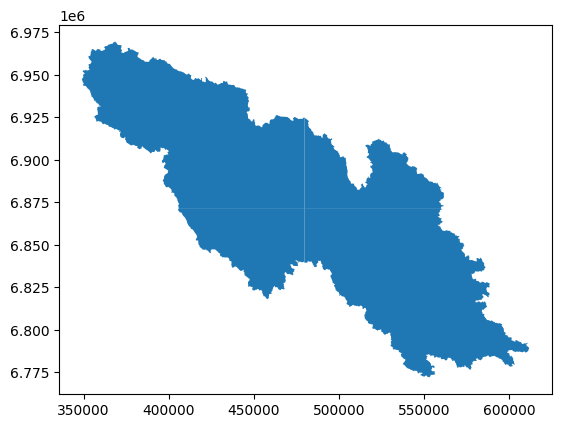

In [42]:
from shapely.geometry import Polygon

gdf_catch = gdf_catch_sorted.loc[gdf_catch_sorted["mvm_id"] == 21]
center_x = gdf_catch.centroid.geometry.x
center_y = gdf_catch.centroid.y
minx = gdf_catch.bounds['minx']
miny = gdf_catch.bounds['miny']
maxx = gdf_catch.bounds['maxx']
maxy = gdf_catch.bounds['maxy']

rectangle_bl = Polygon([[minx, miny],
                                      [minx, center_y],
                                      [center_x,center_y],
                                      [center_x, miny],
                                      [minx, miny]])
rectangle_br = Polygon([[maxx, miny],
                                      [maxx, center_y],
                                      [center_x,center_y],
                                      [center_x, miny],
                                      [maxx, miny]])
rectangle_tr = Polygon([[maxx, maxy],
                                      [maxx, center_y],
                                      [center_x,center_y],
                                      [center_x, maxy],
                                      [maxx, maxy]])
rectangle_tl = Polygon([[minx, maxy],
                                      [minx, center_y],
                                      [center_x,center_y],
                                      [center_x, maxy],
                                      [minx, maxy]])

polygon_bl = gpd.GeoDataFrame(index=[0], crs="EPSG:3006", geometry=[rectangle_bl])
polygon_br = gpd.GeoDataFrame(index=[1], crs="EPSG:3006", geometry=[rectangle_br])
polygon_tr = gpd.GeoDataFrame(index=[2], crs="EPSG:3006", geometry=[rectangle_tr])
polygon_tl = gpd.GeoDataFrame(index=[3], crs="EPSG:3006", geometry=[rectangle_tl])
polygons = pd.concat([polygon_bl, polygon_br, polygon_tl, polygon_tr])
print(polygons)
split_catch = gpd.overlay(gdf_catch, polygons, how='intersection').reset_index()
split_catch.plot()


In [ ]:
import rasterstats as rs
import geopandas as gpd
import pandas as pd

# Load catchments (polygons)
# Load catchments (polygons)
gdf_catch_sorted = gpd.read_file(r"C:\sim\Anna\Repositories\DOC_catchments\shapefiles\catch_316.zip").sort_values(by = 'Shape_Area', ascending = False)

gdf_catch = gdf_catch_sorted.iloc[:30]

# Path to raster
raster_path = r"\\gis.slu.se\gisdata\slu\Torvkarta_1_0\Klassad_torvkarta\ClassifiedPeatMap.tif"

# Calculate zonal statistics (area for each class in the raster)
stats = rs.zonal_stats(gdf_catch, raster_path, stats="sum", band = 1, categorical  = True,  geojson_out = True)

# Display the results
print("done")

out = pd.json_normalize(pd.DataFrame(stats)['properties'])
out['sum'] = pd.to_numeric(out['sum'], errors = 'coerce')
out['Shape_Area'] = pd.to_numeric(out['Shape_Area'], errors = 'coerce')
out['coverage'] = out['Shape_Area']/(4 * out['sum']) * 100

out.to_csv('peat_area_by_class_larger.csv')

,mvm_id,lat,lon,AU_CD,Shape_Leng,Shape_Area,geometry
186,35570.0,6553060.0,463703.0,655386-141596,597372.953501,4.409778e+09,"POLYGON ((440083.089 6694557.813, 440257.474 6..."
185,34989.0,6568140.0,469465.0,657195-142358,554095.204981,4.341155e+09,"POLYGON ((440083.089 6694557.813, 440257.474 6..."
99,587.0,6586310.0,399609.0,658689-135102,486856.348998,4.141586e+09,"POLYGON ((380885.962 6724973.326, 381003.14 67..."
276,26.0,6199820.0,451131.0,620218-140073,464809.469149,4.133482e+09,"POLYGON ((459569.658 6319597.85, 459774.683 63..."
279,29002.0,6200090.0,451191.0,620218-140073,464769.469149,4.133479e+09,"POLYGON ((459569.658 6319597.85, 459774.683 63..."
...,...,...,...,...,...,...,...
3,1821.0,7084550.0,653124.0,708534-161332,3936.412956,4.366071e+05,"POLYGON ((653220 7084970, 653220 7084950, 6532..."
120,193.0,7133432.0,731433.0,713087-169457,4205.342307,3.428221e+05,"POLYGON ((730845.715 7135150, 730890.944 71350..."
2,1815.0,6330290.0,473043.0,633181-142382,2780.197525,2.144475e+05,"POLYGON ((473020 6330350, 473075 6330285, 4730..."
4,1817.0,6623930.0,495022.0,662723-145047,2324.498643,1.867857e+05,"POLYGON ((494550 6624360, 494550 6624340, 4945..."
